In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

df = pd.read_csv('../data/processed/housing_clean.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (17486, 17)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household,income_bracket
0,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False,8.288136,0.129516,2.802260,5.0
1,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False,5.817352,0.184458,2.547945,4.0
2,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False,6.281853,0.172096,2.181467,3.0
3,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,False,False,True,False,4.761658,0.231774,2.139896,3.0
4,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,False,False,True,False,4.931907,0.192899,2.128405,3.0


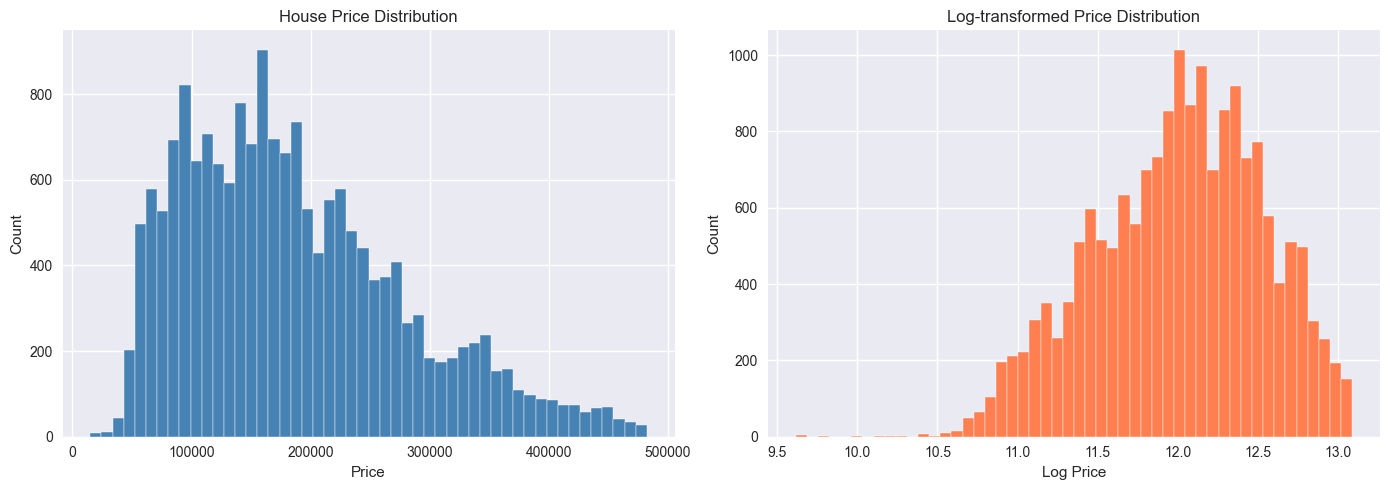

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['median_house_value']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log-transformed Price Distribution')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/price_distribution.png', dpi=150)
plt.show()

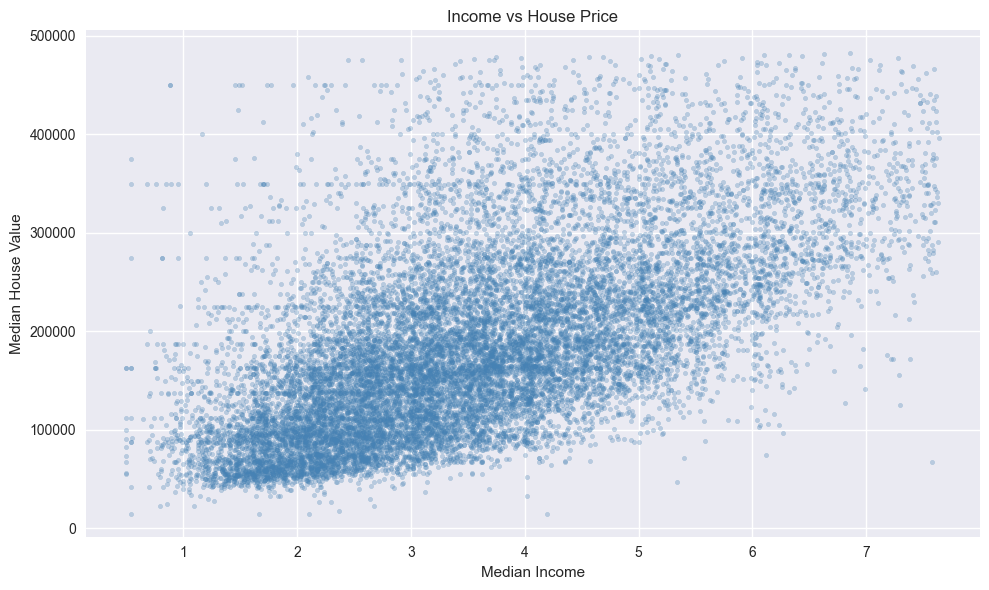

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(df['median_income'], df['median_house_value'],
            alpha=0.3, c='steelblue', s=10)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Income vs House Price')
plt.tight_layout()
plt.savefig('../data/processed/income_vs_price.png', dpi=150)
plt.show()

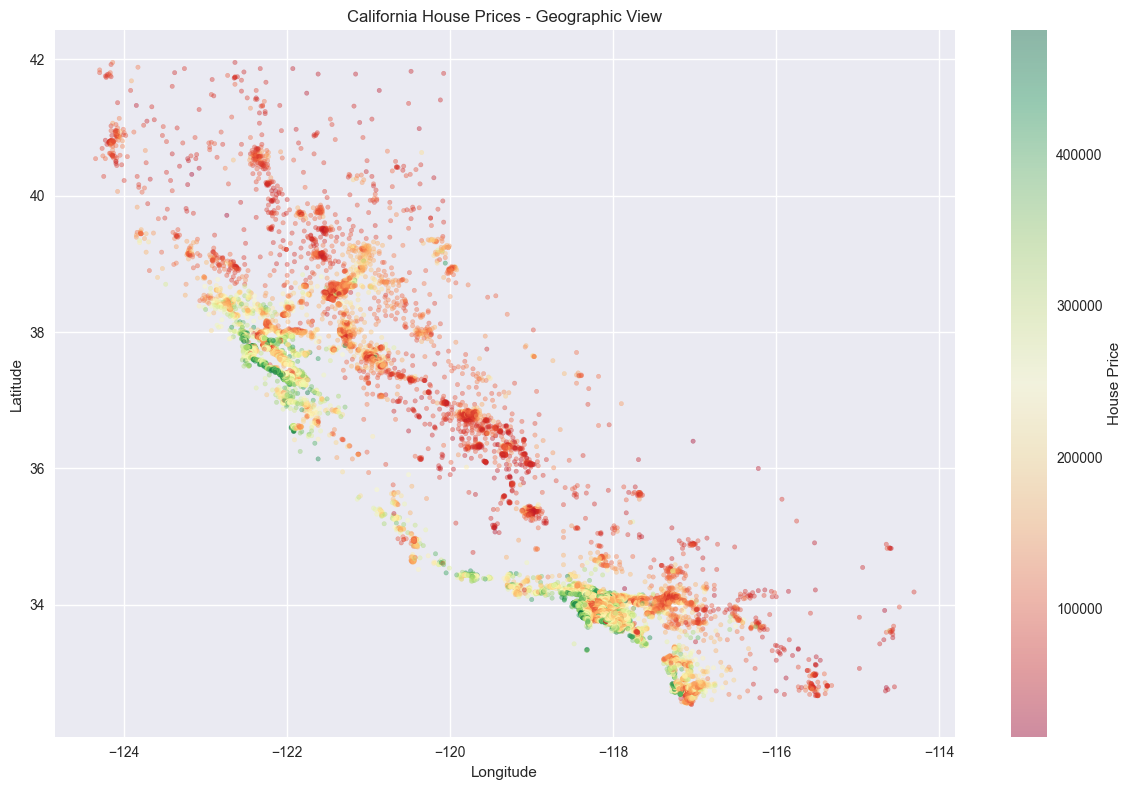

In [4]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['median_house_value'],
    cmap='RdYlGn', alpha=0.4, s=10
)
plt.colorbar(scatter, label='House Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California House Prices - Geographic View')
plt.tight_layout()
plt.savefig('../data/processed/geographic_heatmap.png', dpi=150)
plt.show()

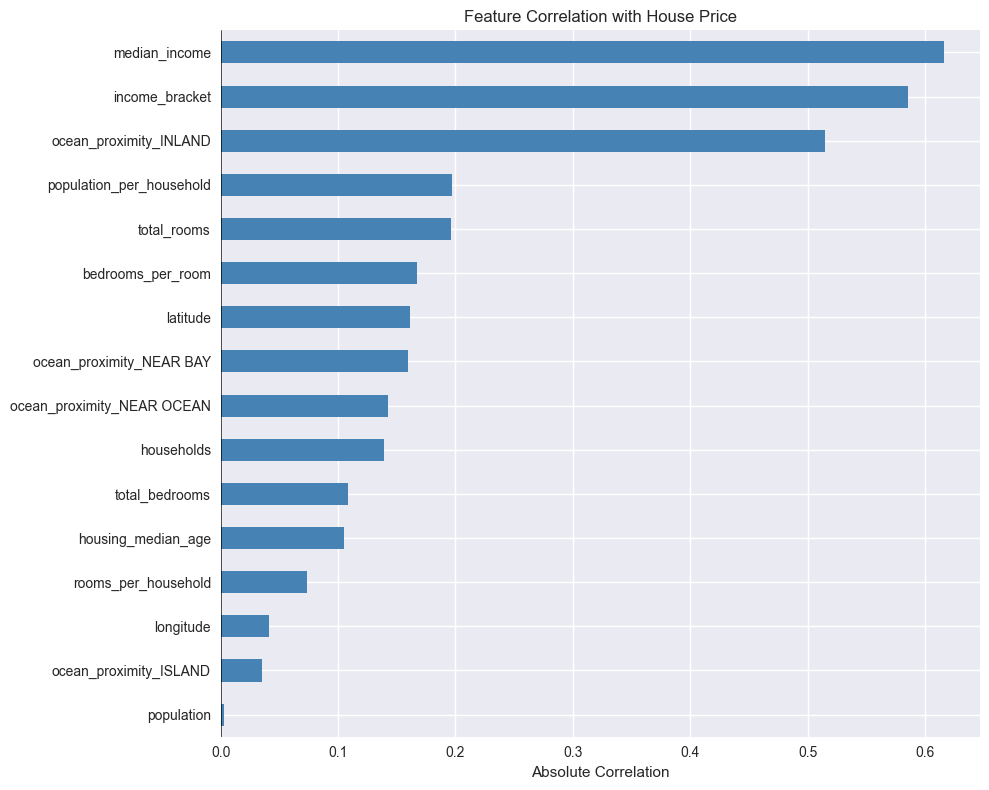

In [5]:
corr = df.corr(numeric_only=True)['median_house_value'].drop('median_house_value')
corr_sorted = corr.abs().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['coral' if x < 0 else 'steelblue' for x in corr_sorted]
corr_sorted.plot(kind='barh', color=colors)
plt.title('Feature Correlation with House Price')
plt.xlabel('Absolute Correlation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../data/processed/feature_correlation.png', dpi=150)
plt.show()

In [6]:
print("=== EDA Summary ===")
print(f"Total records: {len(df)}")
print(f"Features: {df.shape[1]}")
print(f"\nPrice range:")
print(f"  Min: ${df['median_house_value'].min():,.0f}")
print(f"  Max: ${df['median_house_value'].max():,.0f}")
print(f"  Mean: ${df['median_house_value'].mean():,.0f}")
print(f"\nStrongest predictor: median_income (correlation: 0.616)")
print(f"\nEDA Complete! 4 plots saved to data/processed/")

=== EDA Summary ===
Total records: 17486
Features: 17

Price range:
  Min: $14,999
  Max: $482,200
  Mean: $186,477

Strongest predictor: median_income (correlation: 0.616)

EDA Complete! 4 plots saved to data/processed/
